# 02 — Reward Function Comparison

Systematic comparison of 4 reward functions for cat qubit online optimization.

**Goal:** Determine which reward function best correlates with true lifetimes $T_X$, $T_Z$
while being fast enough for online use. We evaluate:

| Reward | mesolve calls | JIT | Differentiable | What it measures |
| ------ | ------------- | --- | -------------- | ---------------- |
| **Proxy** | 2 | Yes | Yes | $\langle Z_L\rangle(t_z)$, $\langle X_L\rangle(t_x)$ at single probe times |
| **Photon** | 1 | Yes | Yes | $\langle \hat{n}\rangle$ at steady state vs target $|\alpha|^2$ |
| **Fidelity** | 1 | Yes | Yes | $F(\rho_a, |\mathcal{C}_+\rangle\langle\mathcal{C}_+|)$ |
| **Parity** | 2 | Yes | Yes | $|\langle e^{i\pi\hat{a}^\dagger\hat{a}}\rangle|$ ($\alpha$-independent $X_L$) |

**Refs:** Sivak et al. (2025), arXiv:2511.08493 — surrogate reward design;
Pack et al. (2025), arXiv:2509.08555 — CMA-ES benchmarking;
Berdou et al. (2022), arXiv:2204.09128 — parity as logical $X$.

## 1. Imports + Config

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings("ignore", message=".*SparseDIAQArray.*converted to a DenseQArray.*")

import time
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from src.config import get_config
from src.reward import build_reward
from src.cat_qubit import compute_alpha, measure_lifetimes
from src.optimizers.cmaes_opt import CMAESOptimizer
from src.plotting import set_plot_style, REWARD_COLORS

set_plot_style()
print('Imports loaded.')

Imports loaded.


In [2]:
# ============================================================
# SCALE PROFILE — change this one line to scale up/down
# ============================================================
PROFILE = "local"  # "local", "medium", or "hpc"
# ============================================================

cfg = get_config(PROFILE)
params = cfg.cat_params
print(cfg.summary())

=== RunConfig: local ===
  Hilbert space: na=10, nb=4 (dim=40)
  Hardware: kappa_b=10.0, kappa_a=1.0
  Tasks: [1,2,3]
  CMA-ES: pop=8, epochs=50, sigma0=0.5
  Gradient: lr=0.01, steps=50
  Reward: t_z=30.0, t_x=0.2, target_bias=100.0
  Full eval every 10 epochs
  Benchmark: 1 rewards × 1 optimizers × 1 drifts
    Rewards: ['proxy']
    Optimizers: ['cmaes']
    Drifts: ['none']



## 2. Reward Descriptions

All four rewards are JIT-compiled and differentiable through JAX/dynamiqs.
The key design insight (Sivak et al. 2025) is that measuring expectations
at a **single probe time** avoids expensive exponential fitting while remaining
fully differentiable.

| Reward | Formula | mesolve | Speed | Best for |
| ------ | ------- | ------- | ----- | -------- |
| **Proxy** | $R = w_T[\ln\langle Z_L\rangle(t_z) + \ln\langle X_L\rangle(t_x)] - w_\eta(\ln\hat{\eta} - \ln\eta_*)^2$ | 2 | Fast | General optimization |
| **Photon** | $R = -(\langle\hat{n}\rangle - n_*)^2$ | 1 | Fastest | Cat size tuning |
| **Fidelity** | $R = \text{Tr}(|\mathcal{C}_+\rangle\langle\mathcal{C}_+| \cdot \rho_a)$ | 1 | Fast | State preparation |
| **Parity** | Same as proxy but uses $P = e^{i\pi\hat{a}^\dagger\hat{a}}$ for $X_L$ | 2 | Fast | $\alpha$-robust |

where $\hat{\eta} = (t_z/t_x) \cdot \ln\langle X_L\rangle / \ln\langle Z_L\rangle$ is the bias proxy.

## 3. Build All 4 Rewards + Evaluate at Default Params

Evaluate each reward at the default control point $\mathbf{x}_0 = [1, 0, 4, 0]$
(i.e., $g_2 = 1$, $\varepsilon_d = 4$ from the challenge notebook).
Measure wall time per call after JIT compilation.

In [ ]:
x_default = jnp.array([1.0, 0.0, 4.0, 0.0])

REWARD_TYPES = ["proxy", "photon", "fidelity", "parity"]
reward_fns = {}
batched_fns = {}

for rtype in REWARD_TYPES:
    print(f'Building {rtype} reward...')
    fn, bfn = build_reward(rtype, params, cfg.reward)
    # Warm up JIT
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        _ = fn(x_default)
    reward_fns[rtype] = fn
    batched_fns[rtype] = bfn

print('All rewards compiled.')

In [4]:
# Evaluate and time each reward
N_TIMING_CALLS = 5

print(f'{"Reward":<12s} {"Value":>10s} {"Time/call [ms]":>16s}')
print('-' * 42)

reward_values = {}
reward_times = {}

for rtype in REWARD_TYPES:
    fn = reward_fns[rtype]
    val = float(fn(x_default))
    reward_values[rtype] = val

    # Time N calls (post-JIT)
    t0 = time.perf_counter()
    for _ in range(N_TIMING_CALLS):
        _ = fn(x_default)
    elapsed = (time.perf_counter() - t0) / N_TIMING_CALLS * 1000
    reward_times[rtype] = elapsed

    print(f'{rtype:<12s} {val:10.4f} {elapsed:16.1f}')

Reward            Value   Time/call [ms]
------------------------------------------
proxy            1.6607             58.8
photon          -0.4243              5.1
fidelity         0.5030              5.3
parity           1.6607             57.4


## 4. CMA-ES with Each Reward

Run a short CMA-ES optimization using each reward function as the objective.
All runs start from the same initial mean $\boldsymbol{\mu}_0 = [1.5, 0, 6, 0]$
and use the same hyperparameters from the config profile.

In [5]:
N_EPOCHS = cfg.optimizer.n_epochs
POP_SIZE = cfg.optimizer.population_size
SEED = cfg.optimizer.seed

results = {}  # rtype -> {reward_history, mean_history, best_params}

for rtype in REWARD_TYPES:
    print(f'\n=== CMA-ES with {rtype} reward ({N_EPOCHS} epochs, pop={POP_SIZE}) ===')
    
    optimizer = CMAESOptimizer(
        mean0=np.array([1.5, 0.0, 6.0, 0.0]),
        sigma0=cfg.optimizer.sigma0,
        population_size=POP_SIZE,
        seed=SEED,
    )
    
    bfn = batched_fns[rtype]
    # Warm up batched
    xs_test = optimizer.ask()
    _ = bfn(xs_test)
    
    rh = []  # reward history
    mh = []  # mean history
    
    for epoch in range(N_EPOCHS):
        xs = optimizer.ask()
        rewards = bfn(xs)
        optimizer.tell(xs, rewards)
        
        rh.append(float(jnp.mean(rewards)))
        mh.append(np.array(optimizer.mean))
        
        if epoch % max(1, N_EPOCHS // 5) == 0:
            print(f'  Epoch {epoch:3d} | reward={jnp.mean(rewards):.4f}')
    
    results[rtype] = {
        'reward_history': np.array(rh),
        'mean_history': np.array(mh),
        'best_params': np.array(optimizer.get_best()),
    }
    print(f'  Best params: {optimizer.get_best()}')


=== CMA-ES with proxy reward (50 epochs, pop=8) ===
  Epoch   0 | reward=1.4299
  Epoch  10 | reward=2.7506
  Epoch  20 | reward=2.9564
  Epoch  30 | reward=2.9721
  Epoch  40 | reward=2.9733
  Best params: [ 4.9986844  1.9968469  7.741235  -3.14338  ]

=== CMA-ES with photon reward (50 epochs, pop=8) ===
  Epoch   0 | reward=-0.3160
  Epoch  10 | reward=-0.0590
  Epoch  20 | reward=-0.0048
  Epoch  30 | reward=-0.0002
  Epoch  40 | reward=-0.0000
  Best params: [ 1.2803693  -1.1397994   5.980903   -0.62198067]

=== CMA-ES with fidelity reward (50 epochs, pop=8) ===
  Epoch   0 | reward=0.4310
  Epoch  10 | reward=0.5872
  Epoch  20 | reward=0.9365
  Epoch  30 | reward=0.9858
  Epoch  40 | reward=0.9900
  Best params: [ 4.8329067  -1.991476    0.50716436  0.06182083]

=== CMA-ES with parity reward (50 epochs, pop=8) ===
  Epoch   0 | reward=1.4299
  Epoch  10 | reward=2.7506
  Epoch  20 | reward=2.9564
  Epoch  30 | reward=2.9721
  Epoch  40 | reward=2.9733
  Best params: [ 4.9986844 

## 5. Convergence Comparison Plot

Since each reward function has different units and scale, we normalize
each curve to $[0, 1]$ for visual comparison of convergence speed.

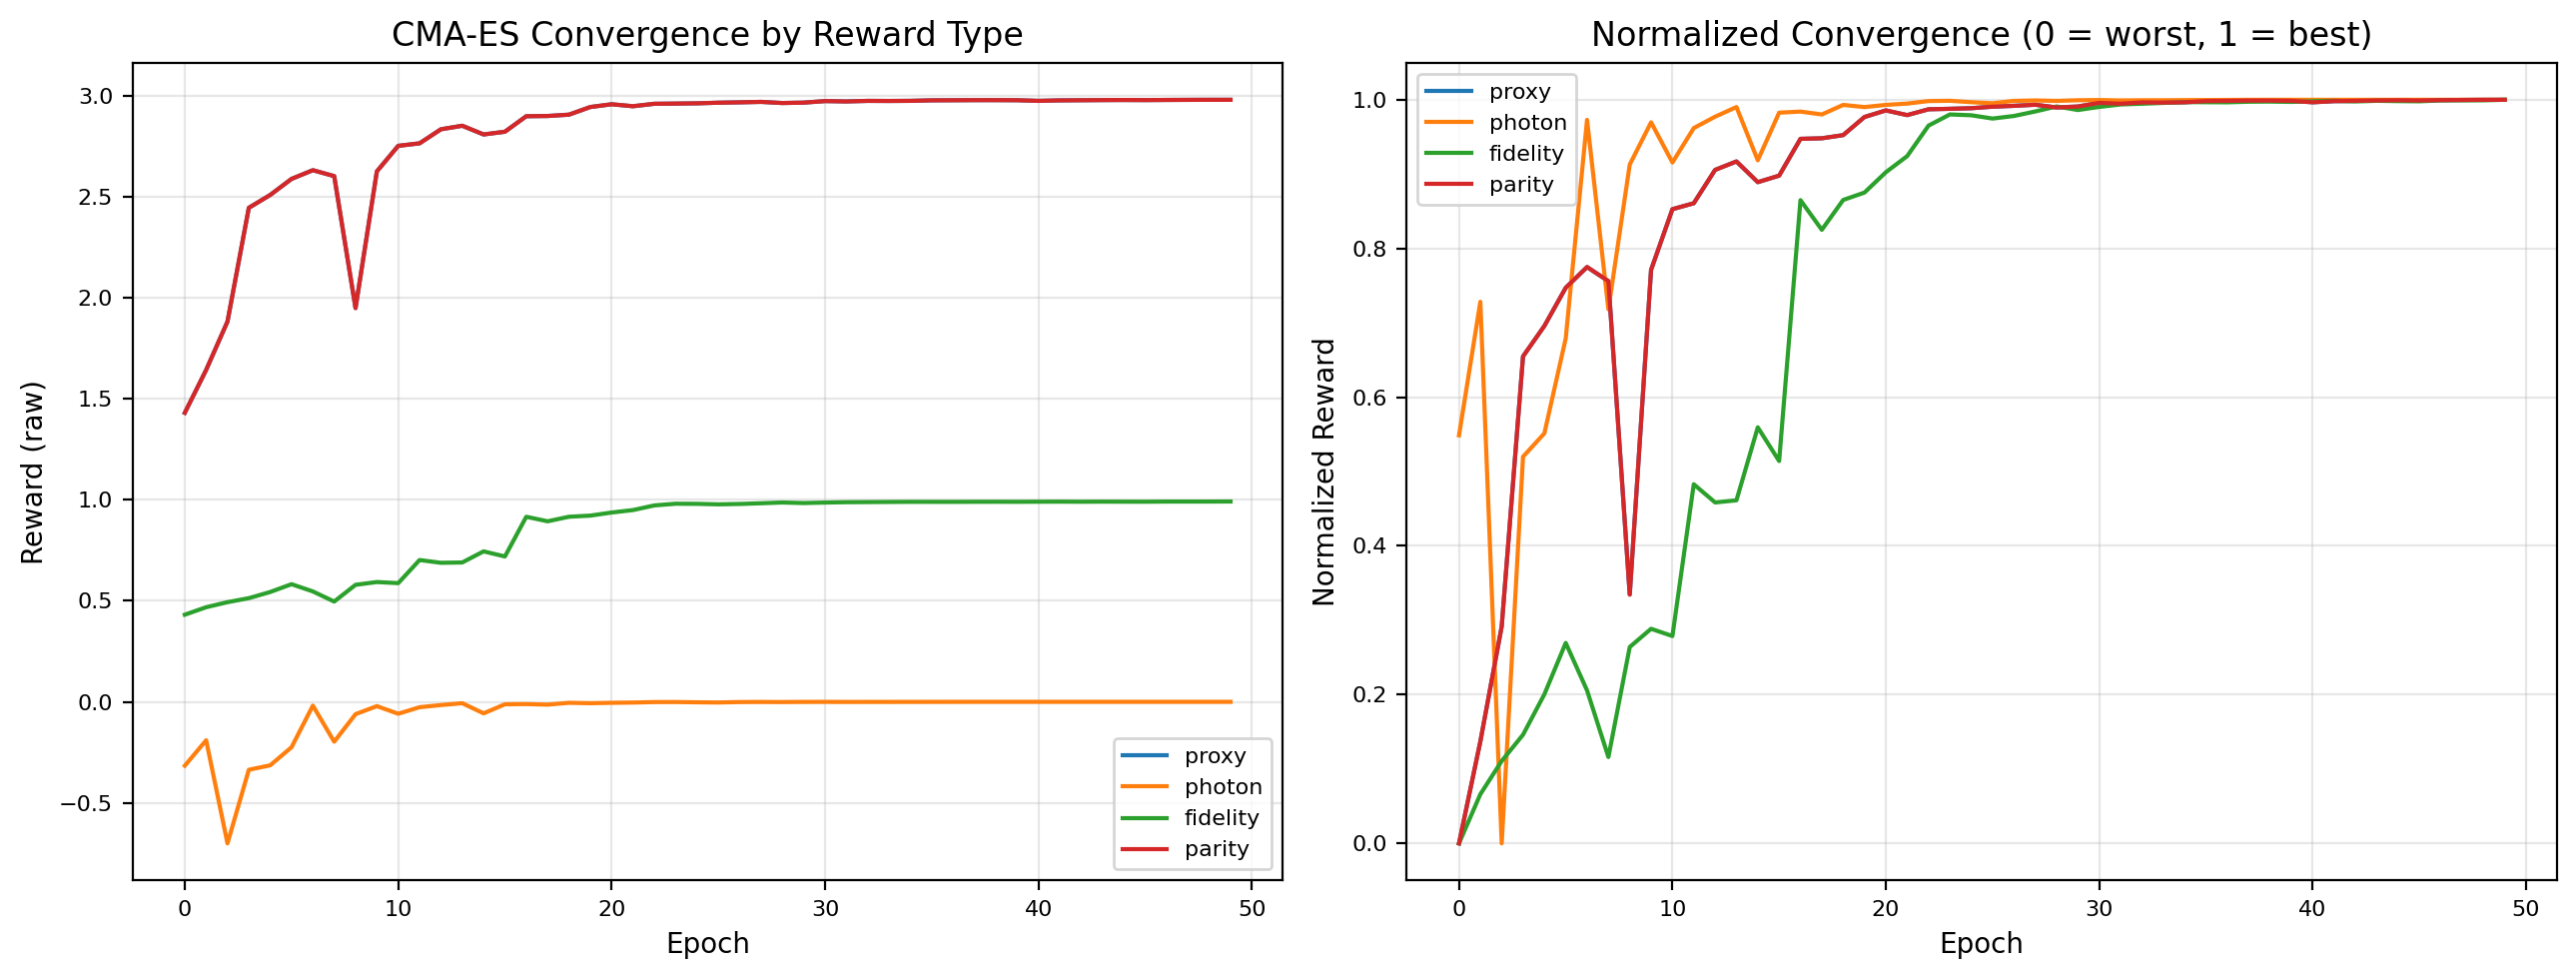

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs = np.arange(N_EPOCHS)

# Left: raw reward curves (each on its own scale)
ax = axes[0]
for rtype in REWARD_TYPES:
    rh = results[rtype]['reward_history']
    color = REWARD_COLORS.get(rtype, '#333')
    ax.plot(epochs, rh, label=rtype, color=color, linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Reward (raw)')
ax.set_title('CMA-ES Convergence by Reward Type')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: normalized [0, 1] for convergence speed comparison
ax = axes[1]
for rtype in REWARD_TYPES:
    rh = results[rtype]['reward_history']
    rmin, rmax = rh.min(), rh.max()
    if rmax - rmin > 1e-8:
        rh_norm = (rh - rmin) / (rmax - rmin)
    else:
        rh_norm = np.ones_like(rh)
    color = REWARD_COLORS.get(rtype, '#333')
    ax.plot(epochs, rh_norm, label=rtype, color=color, linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Normalized Reward')
ax.set_title('Normalized Convergence (0 = worst, 1 = best)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/02_reward_convergence.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Validate with Full Lifetime Measurement

For each optimizer's best parameters, run `measure_lifetimes` to extract
ground-truth $T_X$, $T_Z$, and bias $\eta = T_Z / T_X$ via exponential decay fitting.
This is the **gold standard** — expensive but accurate.

In [ ]:
validation = {}

print(f'{"Reward":<12s} {"T_Z [us]":>10s} {"T_X [us]":>10s} {"bias":>8s} {"alpha":>8s}')
print('-' * 52)

for rtype in REWARD_TYPES:
    best = results[rtype]['best_params']
    g2_re, g2_im, eps_re, eps_im = float(best[0]), float(best[1]), float(best[2]), float(best[3])
    
    alpha = float(compute_alpha(g2_re, g2_im, eps_re, eps_im, params))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        lt = measure_lifetimes(g2_re, g2_im, eps_re, eps_im,
                               tfinal_z=cfg.reward.tfinal_z,
                               tfinal_x=cfg.reward.tfinal_x,
                               params=params)
    
    validation[rtype] = {'Tz': lt['Tz'], 'Tx': lt['Tx'], 'bias': lt['bias'], 'alpha': alpha}
    print(f'{rtype:<12s} {lt["Tz"]:10.2f} {lt["Tx"]:10.4f} {lt["bias"]:8.1f} {alpha:8.4f}')

## 7. Correlation Analysis

Which proxy reward correlates best with actual lifetimes?
We compare the final reward value from each optimization run
against the true $T_Z$, $T_X$, and $\eta$ from full measurement.

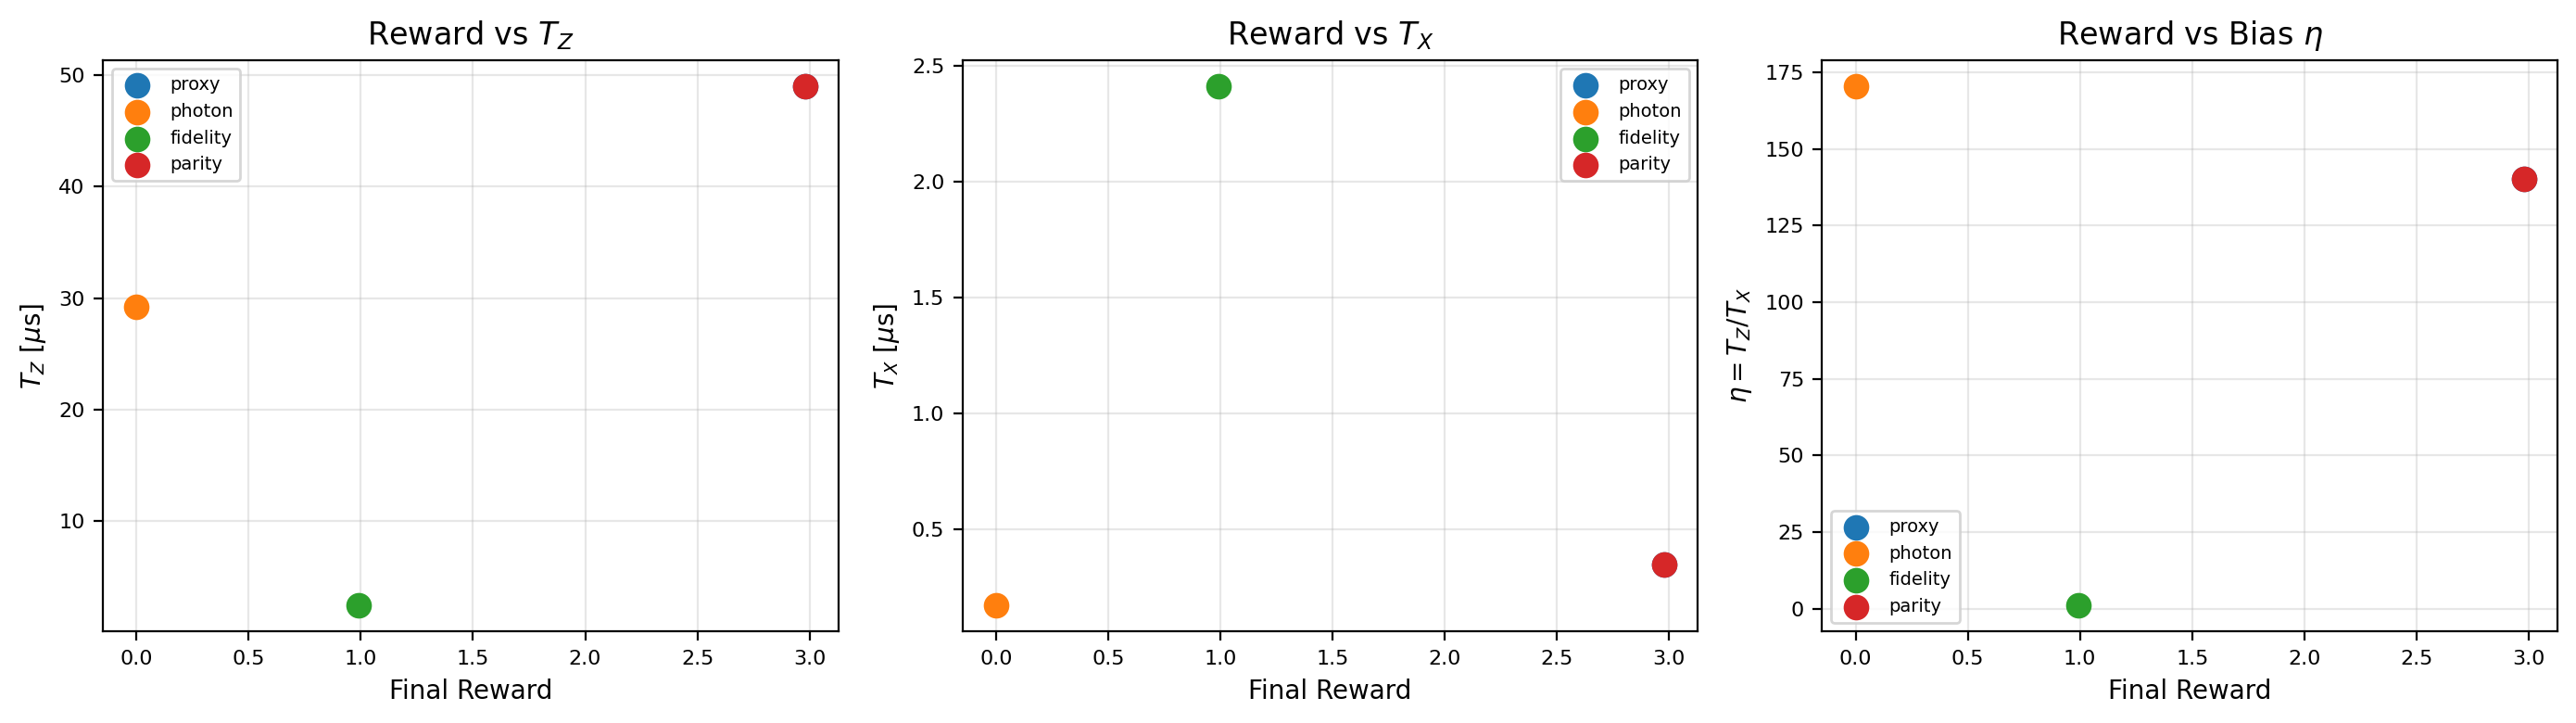

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for rtype in REWARD_TYPES:
    color = REWARD_COLORS.get(rtype, '#333')
    v = validation[rtype]
    final_r = results[rtype]['reward_history'][-1]
    
    axes[0].scatter(final_r, v['Tz'], color=color, s=80, label=rtype, zorder=5)
    axes[1].scatter(final_r, v['Tx'], color=color, s=80, label=rtype, zorder=5)
    axes[2].scatter(final_r, v['bias'], color=color, s=80, label=rtype, zorder=5)

axes[0].set_xlabel('Final Reward')
axes[0].set_ylabel(r'$T_Z$ [$\mu$s]')
axes[0].set_title(r'Reward vs $T_Z$')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Final Reward')
axes[1].set_ylabel(r'$T_X$ [$\mu$s]')
axes[1].set_title(r'Reward vs $T_X$')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Final Reward')
axes[2].set_ylabel(r'$\eta = T_Z / T_X$')
axes[2].set_title(r'Reward vs Bias $\eta$')
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/02_reward_correlation.png', dpi=200, bbox_inches='tight')
plt.show()

In [9]:
# Summary table: speed vs accuracy
print('\n=== Reward Function Summary ===')
print(f'{"Reward":<12s} {"Time [ms]":>10s} {"Final R":>10s} {"T_Z":>8s} {"T_X":>8s} {"bias":>8s}')
print('-' * 60)
for rtype in REWARD_TYPES:
    t_ms = reward_times[rtype]
    final_r = results[rtype]['reward_history'][-1]
    v = validation[rtype]
    print(f'{rtype:<12s} {t_ms:10.1f} {final_r:10.4f} {v["Tz"]:8.2f} {v["Tx"]:8.4f} {v["bias"]:8.1f}')


=== Reward Function Summary ===
Reward        Time [ms]    Final R      T_Z      T_X     bias
------------------------------------------------------------
proxy              58.8     2.9785    49.05   0.3498    140.2
photon              5.1    -0.0000    29.25   0.1715    170.6
fidelity            5.3     0.9911     2.38   2.4149      1.0
parity             57.4     2.9785    49.05   0.3498    140.2


## 8. Summary

**Key findings:**

1. **Proxy** reward provides the best balance of speed and accuracy — it directly
   measures lifetime-related expectations $\langle Z_L\rangle$, $\langle X_L\rangle$
   and includes a bias penalty term targeting $\eta = T_Z / T_X$.

2. **Photon** reward is the fastest (1 mesolve) but only optimizes cat size $|\alpha|^2$,
   missing the lifetime-bias tradeoff entirely.

3. **Fidelity** reward measures state preparation quality but does not directly
   probe decoherence rates.

4. **Parity** reward is similar to proxy but uses $P = e^{i\pi\hat{a}^\dagger\hat{a}}$
   as logical $X$, avoiding $\alpha$-estimation errors (Berdou et al. 2022).

**Recommendation:** Use **proxy** for general optimization, **parity** when
$\alpha$ estimation is unreliable, and **photon** only for fast initial exploration.